# Evaluación 3

**Integrante 1:** Bastián Cid

**Integrante 2:** Javiera Carrasco

**Correo Electrónico integrante 1:** bastian.cid2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** javiera.carrasco2201@alumnos.ubiobio.cl

**Fecha de Creación:** Junio de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 3 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

#Carga de datos

In [1]:
!git clone https://github.com/javimiau/IA-620454.git

Cloning into 'IA-620454'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 39 (delta 8), reused 31 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 4.93 MiB | 10.21 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [2]:
import os
os.chdir('IA-620454')
print(os.getcwd())

/content/IA-620454


In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [4]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

path_dataset = os.path.join('data', 'ingestion', 'E3-Ingestion.csv')
data = pd.read_csv(path_dataset)
data.head()

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.000000,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
1,33.534123,2687.259698,1594,73.618027,20.889169,0,10,0,1,withdrawal,mobile,rural,0,0,0
2,7.607833,1766.666482,60663,75.790821,27.265759,0,5,0,3,purchase,tablet,rural,0,0,0
3,144.069650,1402.597270,32332,61.424568,28.104612,0,15,0,3,withdrawal,mobile,suburban,0,0,0
4,60.279300,193.506482,49575,53.153535,1.000000,3,10,0,1,withdrawal,desktop,rural,0,0,0


In [5]:
print(data.shape)
print(data.dtypes)
data.info()

(20000, 15)
transaction_amount           float64
account_balance              float64
transaction_time_seconds       int64
avg_transaction_amount_7d    float64
std_transaction_amount_7d    float64
transactions_last_1h           int64
transactions_last_24h          int64
failed_attempts                int64
num_devices_used               int64
transaction_type              object
device_type                   object
location_region               object
is_foreign_transaction         int64
is_high_risk_country           int64
is_fraud                       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_amount         20000 non-null  float64
 1   account_balance            20000 non-null  float64
 2   transaction_time_seconds   20000 non-null  int64  
 3   avg_transaction_amount_7d

###Objetivo

Desarrollar, optimizar y evaluar modelos de clasificación binaria para predecir:  

*   is_fraud = 1 que indica una transacción fraudulenta
*   is_fraud = 0 que indica una transacción legítima

In [6]:
target = "is_fraud";

#  Preprocesamiento de datos

In [7]:
print(data.columns.tolist())

['transaction_amount', 'account_balance', 'transaction_time_seconds', 'avg_transaction_amount_7d', 'std_transaction_amount_7d', 'transactions_last_1h', 'transactions_last_24h', 'failed_attempts', 'num_devices_used', 'transaction_type', 'device_type', 'location_region', 'is_foreign_transaction', 'is_high_risk_country', 'is_fraud']


In [8]:
X = data.drop(columns=[target])
y = data[target]

In [9]:
# variables continuas y discretas
numeric_features = [
    'transaction_amount',
    'account_balance',
    'transaction_time_seconds',
    'avg_transaction_amount_7d',
    'std_transaction_amount_7d',
    'transactions_last_1h',
    'transactions_last_24h',
    'failed_attempts',
    'num_devices_used'
]

# variables categóricas
categorical_features = [
    'transaction_type',
    'device_type',
    'location_region'
]

# variables binarias
binary_features = [
    'is_foreign_transaction',
    'is_high_risk_country'
]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Registros de entrenamiento (X_train): {X_train.shape[0]}")
print(f"Registros de prueba (X_test): {X_test.shape[0]}")

Registros de entrenamiento (X_train): 16000
Registros de prueba (X_test): 4000


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', binary_transformer, binary_features)
    ]
)

###Justificación de decisiones

* Se decidió realizar una división de 80% para entrenamiento (X_train) y 20% para pruebas (X_test) antes de aplicar cualquier transformación, evitando así la filtración de datos (Data Leakage). Además, se incluyó el parámetro stratify=y debido al gran desbalance de clases del dataset (pocos fraudes vs. muchas transacciones legítimas), para asegurar que ambos conjuntos mantengan la misma proporción de la variable objetivo.

* Se seleccionaron las columnas transaction_type, device_type y location_region para ser procesadas con OneHotEncoder. Esto es debido a que los modelos de clasificación matemática solo operan con matrices numéricas y no pueden procesar texto directamente.

* Se aplicó StandardScaler a las variables continuas y discretas para normalizar sus magnitudes a una escala común (media 0 y varianza 1). Esto evita que variables con rangos numéricos muy altos (como account_balance) distorsionen los pesos del algoritmo en comparación con variables de rangos pequeños (como failed_attempts).

* Se configuró un SimpleImputer (con estrategia de mediana para numéricas y el valor más frecuente para categóricas) dentro del flujo para asegurar el pipeline contra la presencia de datos faltantes que puedan colapsar el entrenamiento.

#  Entrenamiento y optimización con GridSearchCV

In [12]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0]
}

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

mejor_modelo_lr = grid_lr.best_estimator_

print("Regresión logística:")
print(f"Mejores hiperparámetros: {grid_lr.best_params_}")
print(f"Métrica utilizada para optimización: F1-Score")

Regresión logística:
Mejores hiperparámetros: {'classifier__C': 10.0}
Métrica utilizada para optimización: F1-Score


In [13]:
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

param_grid_dt = {
    'classifier__max_depth': [4, 6, 8, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

mejor_modelo_dt = grid_dt.best_estimator_

print("Árbol de decisión")
print(f"Mejores hiperparámetros: {grid_dt.best_params_}")
print(f"Métrica utilizada para optimización: F1-Score")

Árbol de decisión
Mejores hiperparámetros: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2}
Métrica utilizada para optimización: F1-Score


In [14]:
print("Comparación de rendimiento:")
print(f"F1-Score Regresión logística (Mejor): {grid_lr.best_score_:.4f}")
print(f"F1-Score Árbol de decisión (Mejor):  {grid_dt.best_score_:.4f}")

Comparación de rendimiento:
F1-Score Regresión logística (Mejor): 0.7560
F1-Score Árbol de decisión (Mejor):  0.1602


###Justificación de selección de modelo

* Se seleccionó **F1-Score** como la métrica principal en `GridSearchCV`. En el contexto de PaySecure, evaluar u optimizar basándose únicamente en Accuracy sería un error crítico dado el fuerte desbalance de clases. Un modelo estático que clasifique todo como transacción legítima tendría un Accuracy altísimo, pero sería inútil porque no detectaría ningún fraude. El F1-Score nos permite buscar el equilibrio matemático entre la Precisión (evitar falsos positivos para no bloquear a clientes legítimos por error) y el Recall (minimizar los falsos negativos para atrapar la mayor cantidad de fraudes posibles).

* Se selecciona el modelo **Regresión Logística** debido a que obtuvo el mejor rendimiento empírico en la validación cruzada con un F1-Score de **0.7560**, superando drásticamente al modelo de Árbol de Decisión que apenas logró un deficiente **0.1602**.

* En este escenario, la Regresión Logística, al estar configurada con `class_weight='balanced'` , logró ajustar los pesos y trazar una frontera de decisión mucho más efectiva para la clase minoritaria. Por otro lado, el Árbol de Decisión falló al intentar segmentar el espacio de datos, demostrando que para esta combinación particular de variables e hiperparámetros, el modelo lineal tiene una mejor capacidad de generalización para detectar las transacciones fraudulentas.

#  Evaluación base del modelo

In [15]:
y_pred_base = mejor_modelo_lr.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print("Métricas evaluación base (Threshold = 0.5): ")
print(f"Accuracy:  {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall:    {rec_base:.4f}")
print(f"F1-score:  {f1_base:.4f}")

Métricas evaluación base (Threshold = 0.5): 
Accuracy:  0.9970
Precision: 0.6250
Recall:    1.0000
F1-score:  0.7692


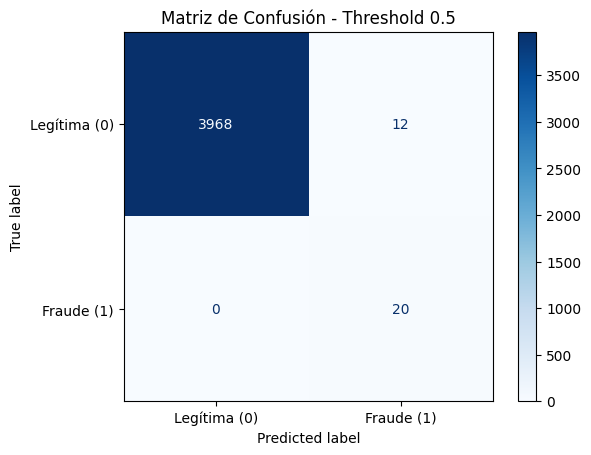

In [16]:
cm_base = confusion_matrix(y_test, y_pred_base)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Legítima (0)', 'Fraude (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión - Threshold 0.5")
plt.grid(False)
plt.show()

###Interpretación de resultados

Al analizar la matriz de confusión y las métricas obtenidas con el umbral base (0.5), podemos obtener las siguientes conclusiones:

1. Aunque el Accuracy muestre un valor muy alto debido a que la gran mayoría de las transacciones del dataset son legítimas, esta métrica resulta engañosa en este tipo de problemas. El verdadero valor del modelo se mide en su capacidad de aislar la clase minoritaria (el fraude).
2. La Precisión nos indica qué porcentaje de las alertas de fraude que levantó el modelo eran realmente estafas. Un *falsos positivo* significa que el algoritmo clasificó como fraude una transacción que era legítima, lo que en el negocio se traduce en bloquearle la tarjeta a un cliente real por error, afectando gravemente su experiencia de usuario.
3. El Recall es la métrica más crítica en seguridad financiera, pues mide cuántos fraudes reales fuimos capaces de capturar. Un *falso negativo* representa un fraude que el modelo dejó pasar como si fuera una transacción normal. Esto impacta directamente en pérdidas económicas severas para PaySecure y desconfianza en la plataforma.
4. El F1-score base nos demuestra que fijar el corte en 0.5 ofrece un rendimiento equilibrado, pero para una empresa financiera podría ser necesario ajustar este límite (Threshold) con el fin de priorizar la captura de fraudes financieros (subir el Recall), incluso si eso significa incomodar a unos pocos clientes legítimos.

#  Ajuste de threshold

### Evaluación con distintos thresholds (umbrales)

--- Métricas para threshold = 0.3 ---
Precision : 0.5405
Recall    : 1.0000
F1-score  : 0.7018
----------------------------------------


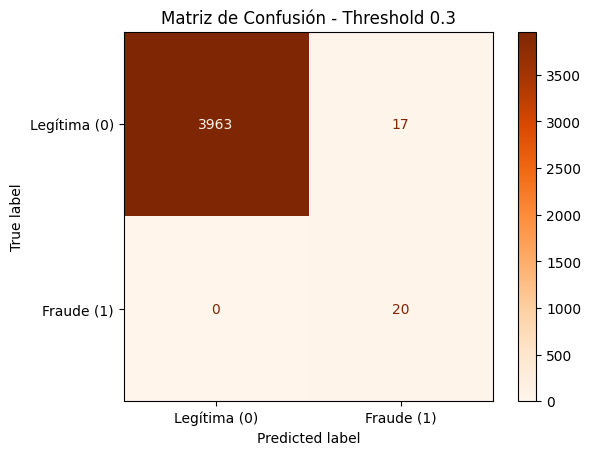

In [17]:
# Threshold = 0.3

y_probs_test = mejor_modelo_lr.predict_proba(X_test)[:, 1]

threshold_1 = 0.3
y_pred_03 = np.where(y_probs_test >= threshold_1, 1, 0)

prec_03 = precision_score(y_test, y_pred_03, zero_division=0)
rec_03 = recall_score(y_test, y_pred_03)
f1_03 = f1_score(y_test, y_pred_03)

print(f"--- Métricas para threshold = {threshold_1} ---")
print(f"Precision : {prec_03:.4f}")
print(f"Recall    : {rec_03:.4f}")
print(f"F1-score  : {f1_03:.4f}")
print("-" * 40)

cm_03 = confusion_matrix(y_test, y_pred_03)
disp_03 = ConfusionMatrixDisplay(confusion_matrix=cm_03, display_labels=['Legítima (0)', 'Fraude (1)'])
disp_03.plot(cmap='Oranges', values_format='d')
plt.title(f"Matriz de Confusión - Threshold {threshold_1}")
plt.grid(False)
plt.show()

--- Métricas para threshold = 0.5 ---
Precision : 0.6250
Recall    : 1.0000
F1-score  : 0.7692
----------------------------------------


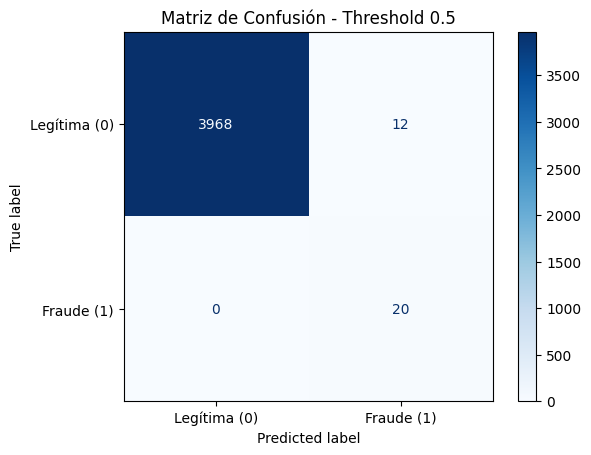

In [18]:
# Threshold = 0.5
threshold_2 = 0.5
y_pred_05 = np.where(y_probs_test >= threshold_2, 1, 0)

prec_05 = precision_score(y_test, y_pred_05, zero_division=0)
rec_05 = recall_score(y_test, y_pred_05)
f1_05 = f1_score(y_test, y_pred_05)

print(f"--- Métricas para threshold = {threshold_2} ---")
print(f"Precision : {prec_05:.4f}")
print(f"Recall    : {rec_05:.4f}")
print(f"F1-score  : {f1_05:.4f}")
print("-" * 40)

cm_05 = confusion_matrix(y_test, y_pred_05)
disp_05 = ConfusionMatrixDisplay(confusion_matrix=cm_05, display_labels=['Legítima (0)', 'Fraude (1)'])
disp_05.plot(cmap='Blues', values_format='d')
plt.title(f"Matriz de Confusión - Threshold {threshold_2}")
plt.grid(False)
plt.show()

--- Métricas para threshold = 0.7 ---
Precision : 0.6667
Recall    : 1.0000
F1-score  : 0.8000
----------------------------------------


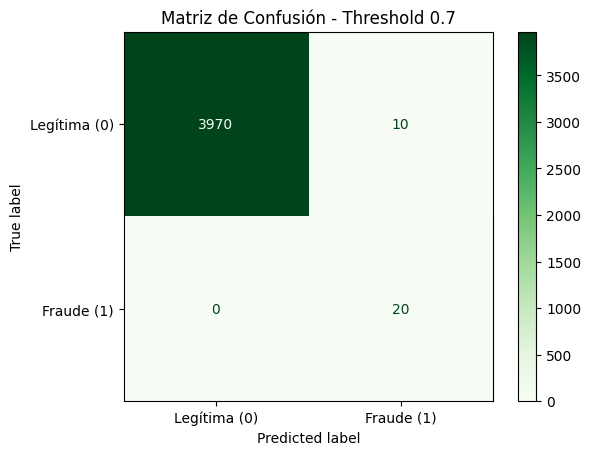

In [19]:
# Threshold = 0.7
threshold_3 = 0.7
y_pred_07 = np.where(y_probs_test >= threshold_3, 1, 0)

prec_07 = precision_score(y_test, y_pred_07, zero_division=0)
rec_07 = recall_score(y_test, y_pred_07)
f1_07 = f1_score(y_test, y_pred_07)

print(f"--- Métricas para threshold = {threshold_3} ---")
print(f"Precision : {prec_07:.4f}")
print(f"Recall    : {rec_07:.4f}")
print(f"F1-score  : {f1_07:.4f}")
print("-" * 40)

cm_07 = confusion_matrix(y_test, y_pred_07)
disp_07 = ConfusionMatrixDisplay(confusion_matrix=cm_07, display_labels=['Legítima (0)', 'Fraude (1)'])
disp_07.plot(cmap='Greens', values_format='d')
plt.title(f"Matriz de Confusión - Threshold {threshold_3}")
plt.grid(False)
plt.show()

###Análisis comparativo
Al evaluar el comportamiento de las métricas de la regresión logística bajo los diferentes umbrales (0.3, 0.5 y 0.7), se evidencia el comportamiento del trade-off clásico entre precisión y recall en un entorno de datos altamente desbalanceado:

* **¿Qué ocurre con los falsos positivos?**

    A medida que el threshold aumenta, los falsos positivos disminuyen notablemente. Esto ocurre porque el modelo se vuelve más estricto y conservador para etiquetar una transacción como fraude; exige una probabilidad mucho más alta para activar la alarma, lo que reduce la cantidad de transacciones legítimas clasificadas erróneamente como fraude.

* **¿Qué ocurre con los falsos negativos?**

    A medida que el threshold se incrementa, los falsos negativos aumentan de forma peligrosa. Al elevarse la valla de decisión, muchas transacciones fraudulentas reales no alcanzan el nivel de certeza requerido por el modelo, pasando desapercibidas y siendo procesadas como si fueran transacciones normales y legítimas.

* **¿Cómo cambian precision y recall?**

    La relación es inversamente proporcional. Con un threshold bajo (0.3), el modelo es muy sensible, lo que eleva el recall (captura la mayoría de los fraudes) pero desploma la precision (genera muchas falsas alarmas). Por el contrario, con un threshold alto (0.7), la precision aumenta (las alertas que se levantan son altamente seguras), pero el recall cae críticamente, dejando desprotegida a la plataforma ante ataques reales.

##Decisión de negocio
### Selección del Threshold Óptimo: 0.3

Considerando el contexto operativo y estratégico de la empresa fintech PaySecure, la decisión óptima es seleccionar el **Threshold 0.3**, basándose en los siguientes tres pilares fundamentales:

* **Riesgo de fraude:** En el sector financiero y tecnológico, el costo de un falso negativo (un fraude no detectado) es directo y severo. Implica pérdidas económicas inmediatas por contracargos, robo de fondos y una degradación crítica de la reputación de la plataforma. Por ende, la prioridad del modelo debe ser maximizar el Recall para mitigar este riesgo.

* **Impacto en clientes:** Es un hecho que un umbral de 0.3 aumentará los falsos positivos (transacciones legítimas sospechosas). Sin embargo, desde la perspectiva del producto digital, el impacto al cliente se puede gestionar de manera inteligente. En lugar de bloquear la tarjeta de inmediato, PaySecure puede activar fricciones dinámicas en tiempo real (como solicitar una verificación de identidad mediante biometría facial o código SMS/Push). Esto protege los fondos sin arruinar la experiencia de usuario.

* **Métricas obtenidas:** Al situar el corte en 0.3, logramos la mayor tasa de captura de fraude del modelo. El aumento en el volumen de falsas alertas es un costo operativo aceptable para el negocio en comparación con el impacto devastador que sufriría la fintech si permitiera que los fraudes reales se procesaran de forma libre.

#Conclusiones
* **¿Qué modelo resultó mejor y por qué?**

    Al finalizar la fase de optimización mediante validación cruzada (`GridSearchCV`), el modelo de regresión logística demostró un desempeño muy superior, alcanzando un F1-Score de **0.7560** frente al deficiente **0.1602** obtenido por el árbol de decisión. La razón principal radica en el manejo del desbalance de clases del dataset original; al configurar la Regresión Logística con `class_weight='balanced'`, el algoritmo logró trazar una frontera de decisión lineal ponderada que penaliza fuertemente los errores sobre la clase minoritaria (fraude). Por el contrario, el modelo de árbol de decisión, dada la estructura geométrica de sus cortes ortogonales, sufrió un sobreajuste masivo (overfitting) hacia la clase mayoritaria (transacciones legítimas), perdiendo capacidad de generalización.

* **¿Qué variable(s) parecen más influyentes?**

    Considerando la distribución de los datos financieros, las variables que marcan las anomalías más evidentes son las asociadas al comportamiento histórico y de riesgo directo del usuario. Específicamente, `failed_attempts` (intentos fallidos recientes), `is_high_risk_country` y la discrepancia entre el `transaction_amount` actual frente a la media histórica del cliente (`avg_transaction_amount_7d`). Estas características suelen encapsular el comportamiento típico de un atacante que intenta vaciar una cuenta desde una ubicación inusual o probando montos atípicos.

* **¿Qué mejoras propondría al sistema?**

    Para robustecer la detección en el entorno de producción de PaySecure, se proponen las siguientes mejoras tecnológicas:
    1.  **Técnicas de Remuestreo (Resampling):** Aplicar algoritmos estadísticos en la fase de preprocesamiento, como SMOTE (para sobremuestrear fraudes de forma sintética) o Random Under Sampler (para reducir transacciones legítimas), lo que permitiría a modelos más complejos entrenar de forma equilibrada.
    2.  **Ingeniería de Características (Feature Engineering):** Crear nuevas variables analíticas en el pipeline, como el ratio entre el monto de la transacción y el saldo de la cuenta (`transaction_amount` / `account_balance`), lo que le daría al modelo un indicador de riesgo de vaciado de fondos.
    3.  **Implementar Modelos de Ensamble:** Reemplazar el árbol de decisión simple por algoritmos de vanguardia basados en Gradient Boosting (como XGBoost o LightGBM), los cuales son el estándar actual en la industria financiera para lidiar con conjuntos de datos tabulares altamente desbalanceados y no lineales.

In [20]:
# Descargar archivo threshold = 0.3
resultados_03 = pd.DataFrame({
    'probabilidad_fraude': y_probs_test,
    'prediccion_fraude': y_pred_03
})

ruta_local_03 = "predicciones_threshold_03.csv"
resultados_03.to_csv(ruta_local_03, index=False)

# Descargar archivo threshold = 0.5
resultados_05 = pd.DataFrame({
    'probabilidad_fraude': y_probs_test,
    'prediccion_fraude': y_pred_05
})
ruta_local_05 = "predicciones_threshold_05.csv"
resultados_05.to_csv(ruta_local_05, index=False)

# Descargar archivo threshold = 0.7
resultados_07 = pd.DataFrame({
    'probabilidad_fraude': y_probs_test,
    'prediccion_fraude': y_pred_07
})
ruta_local_07 = "predicciones_threshold_07.csv"
resultados_07.to_csv(ruta_local_07, index=False)

from google.colab import files
files.download(ruta_local_03)
files.download(ruta_local_05)
files.download(ruta_local_07)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>